# 03 — Model Comparison: LogReg → RandomForest → XGBoost

Same features, same held-out test, same metrics. Each model must **beat the baseline's PR-AUC**. We expect tree models to win because fraud here is driven by *interactions* (high amount **AND** night **AND** online category) that a linear model can't capture.

Imbalance handling: RandomForest `class_weight='balanced_subsample'`, XGBoost `scale_pos_weight = n_legit / n_fraud`.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
MODELS = ROOT / "models"; MODELS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110

import features as F
X_train, y_train, X_test, y_test = F.load_train_test()
print("train:", X_train.shape, "| test:", X_test.shape)

train: (1296675, 23) | test: (555719, 23)


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

models = {
    "LogReg (baseline)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=18, min_samples_leaf=5,
        class_weight="balanced_subsample", n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
        tree_method="hist", eval_metric="aucpr", n_jobs=-1, random_state=42),
}

scale_pos_weight = 171.8


## Train & evaluate all three

In [3]:
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, confusion_matrix)
import joblib

def best_f1_point(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    i = int(np.nanargmax(f1[:-1]))
    return thr[i], prec[i], rec[i], f1[i]

results, curves = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    thr, prec, rec, f1 = best_f1_point(y_test, p)
    results[name] = {
        "PR_AUC": average_precision_score(y_test, p),
        "ROC_AUC": roc_auc_score(y_test, p),
        "best_thr": float(thr), "precision": float(prec),
        "recall": float(rec), "F1": float(f1),
    }
    pr, rc, _ = precision_recall_curve(y_test, p)
    curves[name] = (rc, pr)
    joblib.dump(model, MODELS / f"{name.split()[0].lower()}.joblib")
    print(f"{name:18s} PR-AUC={results[name]['PR_AUC']:.4f}  recall={rec:.3f}  precision={prec:.3f}")

res_df = pd.DataFrame(results).T.round(4)
res_df

LogReg (baseline)  PR-AUC=0.1843  recall=0.584  precision=0.286


RandomForest       PR-AUC=0.8721  recall=0.747  precision=0.896


XGBoost            PR-AUC=0.8728  recall=0.763  precision=0.898


,PR_AUC,ROC_AUC,best_thr,precision,recall,F1
LogReg (baseline),0.1843,0.9641,0.9365,0.2859,0.5841,0.3839
RandomForest,0.8721,0.9967,0.8890,0.8960,0.7473,0.8149
XGBoost,0.8728,0.9975,0.9808,0.8984,0.7627,0.8250


In [4]:
(ROOT / "reports").mkdir(exist_ok=True)
res_df.to_csv(ROOT / "reports" / "model_comparison.csv")
with open(ROOT / "reports" / "model_comparison.json", "w") as f:
    json.dump(results, f, indent=2)
print("saved reports/model_comparison.{csv,json}")

saved reports/model_comparison.{csv,json}


## Overlaid precision-recall curves

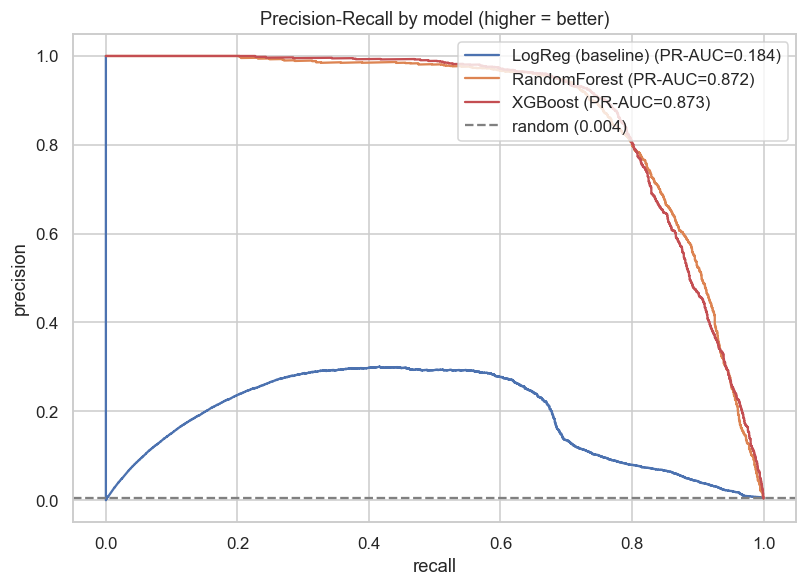

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
palette = {"LogReg (baseline)": "#4c72b0", "RandomForest": "#dd8452", "XGBoost": "#c44e52"}
for name, (rc, pr) in curves.items():
    ax.plot(rc, pr, label=f"{name} (PR-AUC={results[name]['PR_AUC']:.3f})", color=palette[name])
ax.axhline(y_test.mean(), ls="--", color="gray", label=f"random ({y_test.mean():.3f})")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("Precision-Recall by model (higher = better)"); ax.legend(loc="upper right")
fig.tight_layout(); fig.savefig(FIG / "07_model_comparison_pr.png"); plt.show()

## Bar chart: PR-AUC by model

C:\Users\triaz\AppData\Local\Temp\claude\ipykernel_41900\140744912.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pr_aucs.index, y=pr_aucs.values, ax=ax,


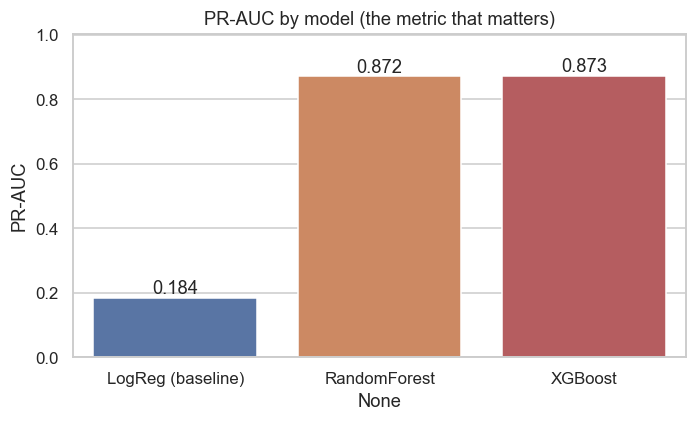

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4))
pr_aucs = res_df["PR_AUC"]
sns.barplot(x=pr_aucs.index, y=pr_aucs.values, ax=ax,
            palette=[palette[n] for n in pr_aucs.index])
for i, v in enumerate(pr_aucs.values):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
ax.set_ylabel("PR-AUC"); ax.set_title("PR-AUC by model (the metric that matters)")
ax.set_ylim(0, max(pr_aucs.values) * 1.15)
fig.tight_layout(); fig.savefig(FIG / "08_pr_auc_bars.png"); plt.show()

## Takeaways

- Tree models capture the amount×time×category interactions the linear baseline misses.
- **XGBoost** is the model we carry forward to hyperparameter tuning + SHAP explainability (notebook 04) and the Streamlit demo.
- Trained models are saved to `models/` for reuse. Metrics are in `reports/model_comparison.{csv,json}` for the final business-impact report.